In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")


In [14]:
markets = {
    "US": "/Users/aaron/Desktop/fyp/ts-node-esm-template/knowledge/csv/US_Sp500_history.csv",
    "UK": "/Users/aaron/Desktop/fyp/ts-node-esm-template/knowledge/csv/UK_FTSE100_history.csv",
    "SG": "/Users/aaron/Desktop/fyp/ts-node-esm-template/knowledge/csv/SG_STI_history.csv",
    "HK": "/Users/aaron/Desktop/fyp/ts-node-esm-template/knowledge/csv/HK_HSI_history.csv",
    "CN": "/Users/aaron/Desktop/fyp/ts-node-esm-template/knowledge/csv/CN_SSE_history.csv",
}

data = {}

for name, path in markets.items():
    df = pd.read_csv(path)

    # Drop the first two metadata rows
    df = df.iloc[2:].copy()

    # Rename columns
    df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]

    # Convert data types
    df["Date"] = pd.to_datetime(df["Date"])
    numeric_cols = ["Close", "High", "Low", "Open", "Volume"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    # Set index
    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)

    # Create Adjusted Close (same as Close for indices)
    df["Adj Close"] = df["Close"]

    data[name] = df

print("All markets cleaned and loaded.")


All markets cleaned and loaded.


In [15]:
for name, df in data.items():
    df["Return"] = df["Adj Close"].pct_change()
    df["Cumulative Return"] = (1 + df["Return"]).cumprod()
    df.dropna(inplace=True)

print("Return features added.")


Return features added.


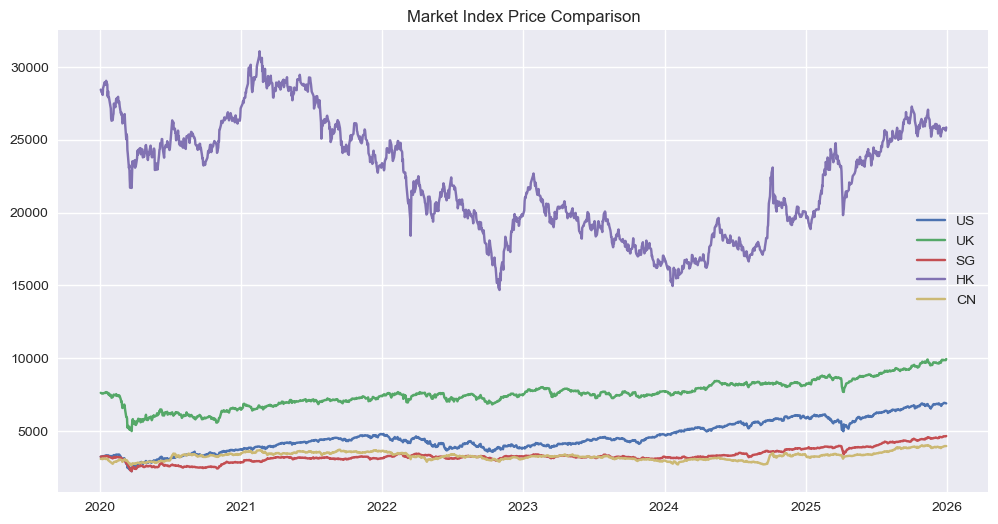

In [16]:
plt.figure(figsize=(12,6))

for name, df in data.items():
    plt.plot(df.index, df["Adj Close"], label=name)

plt.title("Market Index Price Comparison")
plt.legend()
plt.show()


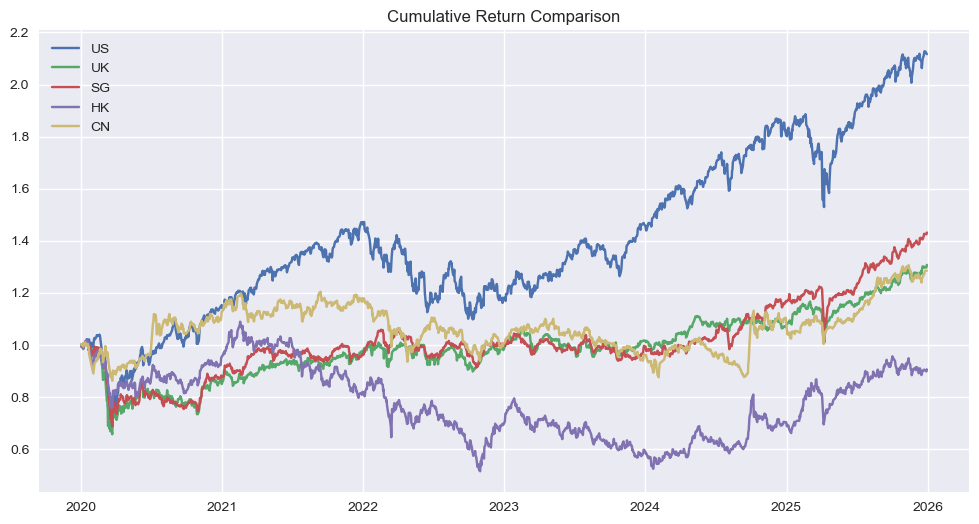

In [17]:
plt.figure(figsize=(12,6))

for name, df in data.items():
    plt.plot(df.index, df["Cumulative Return"], label=name)

plt.title("Cumulative Return Comparison")
plt.legend()
plt.show()


In [19]:
metrics = []

for name, df in data.items():
    annual_return = df["Return"].mean() * 252
    volatility = df["Return"].std() * np.sqrt(252)

    cumulative = df["Cumulative Return"]
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    metrics.append({
        "Market": name,
        "Annual Return": annual_return,
        "Volatility": volatility,
        "Max Drawdown": max_drawdown
    })

metrics_df = pd.DataFrame(metrics)
metrics_df


,Market,Annual Return,Volatility,Max Drawdown
0,US,0.147488,0.209315,-0.339250
1,UK,0.058567,0.166204,-0.349295
2,SG,0.070172,0.142078,-0.319275
3,HK,0.014310,0.249634,-0.527520
4,CN,0.057427,0.166550,-0.272701


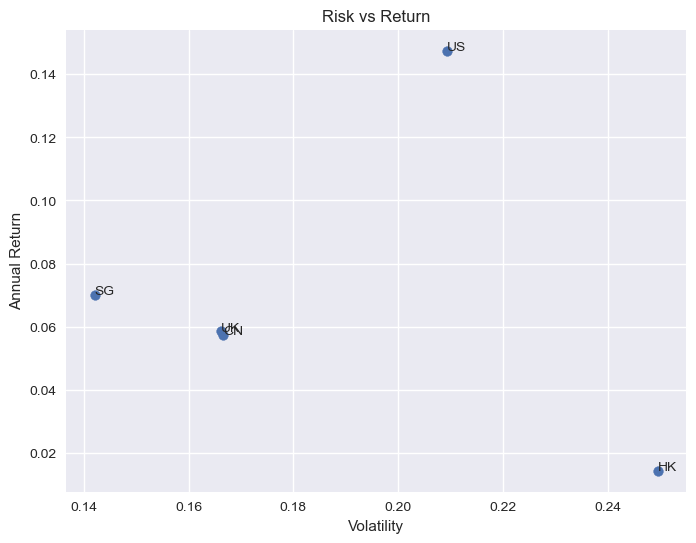

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(metrics_df["Volatility"], metrics_df["Annual Return"])

for i, txt in enumerate(metrics_df["Market"]):
    plt.annotate(txt, (metrics_df["Volatility"][i], metrics_df["Annual Return"][i]))

plt.title("Risk vs Return")
plt.xlabel("Volatility")
plt.ylabel("Annual Return")
plt.show()


In [21]:
def generate_summary(name, df):
    annual_return = df["Return"].mean() * 252
    volatility = df["Return"].std() * np.sqrt(252)

    cumulative = df["Cumulative Return"]
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    max_drawdown = drawdown.min()

    trend = "upward trend" if cumulative.iloc[-1] > 1 else "downward trend"

    return f"""
Market: {name}
Period: {df.index.min().date()} to {df.index.max().date()}

The market showed an overall {trend}.
Annual return was {annual_return:.2%}.
Volatility was {volatility:.2%}.
Maximum drawdown reached {max_drawdown:.2%}.

This indicates a {'strong' if annual_return > 0.08 else 'moderate or weak'} growth profile with {'high' if volatility > 0.2 else 'controlled'} risk.
"""

summaries = []

for name, df in data.items():
    text = generate_summary(name, df)
    summaries.append(text)
    print(text)



Market: US
Period: 2020-01-03 to 2025-12-30

The market showed an overall upward trend.
Annual return was 14.75%.
Volatility was 20.93%.
Maximum drawdown reached -33.92%.

This indicates a strong growth profile with high risk.


Market: UK
Period: 2020-01-03 to 2025-12-30

The market showed an overall upward trend.
Annual return was 5.86%.
Volatility was 16.62%.
Maximum drawdown reached -34.93%.

This indicates a moderate or weak growth profile with controlled risk.


Market: SG
Period: 2020-01-03 to 2025-12-30

The market showed an overall upward trend.
Annual return was 7.02%.
Volatility was 14.21%.
Maximum drawdown reached -31.93%.

This indicates a moderate or weak growth profile with controlled risk.


Market: HK
Period: 2020-01-03 to 2025-12-30

The market showed an overall downward trend.
Annual return was 1.43%.
Volatility was 24.96%.
Maximum drawdown reached -52.75%.

This indicates a moderate or weak growth profile with high risk.


Market: CN
Period: 2020-01-03 to 2025-12-3

In [22]:
with open("market_rag_summaries.txt", "w") as f:
    for s in summaries:
        f.write(s + "\n\n")

print("RAG summaries saved.")


RAG summaries saved.
